# RL Fine-tuning — CPMP Transformer V9

Fine-tuning del modelo pre-entrenado con supervisado usando **REINFORCE**.

### Diseño
- **Algoritmo:** REINFORCE con baseline EMA
- **Reward:** `-total_steps` si resuelve, `-(max_steps × 2)` si no resuelve
- **Regularización:** pérdida supervisada (CE) mezclada con la pérdida RL para evitar catastrofic forgetting
- **Instancias:** generadas aleatoriamente (sin labels BSG) — las 4 configuraciones del SL
- **Evaluación:** benchmark CVS (840 instancias, no vistas durante RL)

### Flujo
1. Generar instancias RL (sin labels)
2. Cargar modelo pre-entrenado `v9_dataBSG_250k`
3. Sanity check de un episodio
4. Training loop con checkpointing
5. Evaluación final sobre CVS

## 1. Setup

In [1]:
import sys
import os

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

src_path = os.path.abspath('src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print('CWD:', os.getcwd())
print('src:', src_path)

CWD: /mnt/data/Proyectos/Universidad/CPMP-Transformer
src: /mnt/data/Proyectos/Universidad/CPMP-Transformer/src


In [2]:
import torch
import numpy as np
from pathlib import Path
from torch.utils.data import DataLoader, ConcatDataset

from models.cpmp_transformer_v9 import CPMPTransformer
from training.training import load_model, load_hyperparams, pad_batch_collate
from training.rl_training import RLTrainer
from generation.instances import generate_instances, read_instance
from preprocessing.dataset import H5Dataset
from settings import INSTANCE_FOLDER, DATA_FOLDER, MODELS_FOLDER

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

Dispositivo: cuda


## 2. Generar instancias de entrenamiento RL

Solo necesitamos los estados iniciales — **sin labels BSG**. Las 4 configuraciones del SL para mantener la distribución.

In [3]:
RL_CONFIGS = [
    (5,  4, 15, 'rl_E4',  5000),   # Pequeños
    (7,  5, 25, 'rl_E5',  5000),   # Intermedios
    (8,  6, 40, 'rl_E6b', 5000),   # Medianos-difíciles (reemplaza H=10)
    (6,  7, 30, 'rl_E7',  5000),   # Anchos
]

RL_SEED = 100
R_DESORDEN = 50
MAX_STEPS = 100    # Aumentado de 50 — evita cortar episodios en instancias difíciles

In [4]:
print('Generando instancias RL...')
for H, S, N, basename, amount in RL_CONFIGS:
    folder = INSTANCE_FOLDER / basename
    if folder.exists() and len(list(folder.glob('*.txt'))) >= amount:
        print(f'  {basename}: ya existen {amount} instancias, saltando.')
        continue
    generate_instances(basename, H, S, N, amount, r=R_DESORDEN, seed=RL_SEED)
    print(f'  {basename}: {amount} instancias generadas.')
print('Listo.')

Generando instancias RL...
  rl_E4: ya existen 5000 instancias, saltando.
  rl_E5: ya existen 5000 instancias, saltando.
  rl_E6b: ya existen 5000 instancias, saltando.
  rl_E7: ya existen 5000 instancias, saltando.
Listo.


In [5]:
# Cargar todos los Layout en memoria
rl_layouts = []
for H, S, N, basename, amount in RL_CONFIGS:
    folder = INSTANCE_FOLDER / basename
    files = sorted(folder.glob('*.txt'))[:amount]
    for f in files:
        rl_layouts.append(read_instance(str(f), H))

print(f'Total instancias RL cargadas: {len(rl_layouts)}')

Total instancias RL cargadas: 20000


## 3. Cargar modelo pre-entrenado

In [6]:
MODEL_NAME = 'v9_dataBSG_250k'

model = load_model(CPMPTransformer, MODEL_NAME)
model = model.to(device)
print(f'Modelo {MODEL_NAME} cargado.')
print(f'Parámetros: {sum(p.numel() for p in model.parameters()):,}')

Modelo v9_dataBSG_250k cargado.
Parámetros: 285,184


## 4. Dataset supervisado (para regularización SL)

Se usa para mezclar pérdida CE con la pérdida RL y evitar catastrofic forgetting.

In [7]:
SL_DATA_FILES = [
    'E4-15-H5_V9_BSG.data',
    'E5-25-H7_V9_BSG.data',
    'E6-45-H10_V9_BSG.data',
    'E7-30-H6_V9_BSG.data',
]

sl_datasets = []
for fname in SL_DATA_FILES:
    path = DATA_FOLDER / fname
    if path.exists():
        sl_datasets.append(H5Dataset(str(path)))
        print(f'  Cargado: {fname}')
    else:
        print(f'  No encontrado (opcional): {fname}')

sl_loader = None
if sl_datasets:
    sl_dataset = ConcatDataset(sl_datasets)
    sl_loader = DataLoader(
        sl_dataset,
        batch_size=64,
        shuffle=True,
        num_workers=2,
        pin_memory=(device.type == 'cuda'),
        collate_fn=pad_batch_collate,
        drop_last=True,
    )
    print(f'\nDataLoader SL listo: {len(sl_dataset):,} muestras.')
else:
    print('\nSin dataset SL — entrenando solo con RL (más inestable).')

  Cargado: E4-15-H5_V9_BSG.data
  Cargado: E5-25-H7_V9_BSG.data
  Cargado: E6-45-H10_V9_BSG.data
  Cargado: E7-30-H6_V9_BSG.data

DataLoader SL listo: 249,944 muestras.


## 5. Inicializar RLTrainer

In [8]:
trainer = RLTrainer(
    model=model,
    device=device,
    learning_rate=1e-5,
    entropy_coeff=0.01,
    sl_coeff=0.3,        # Empieza en 0.3
    sl_coeff_min=0.15,   # Nunca baja de 0.15
    sl_coeff_decay=0.85, # Decae un 15% por epoch (no por batch)
    baseline_decay=0.99,
    max_steps=MAX_STEPS,
    grad_clip=1.0,
)
print('RLTrainer listo.')
print(f'sl_coeff schedule: {0.3:.2f} → {0.3*0.85:.2f} → {0.3*0.85**2:.2f} → ... → {0.15:.2f} (min en epoch ~{int(__import__("math").log(0.15/0.3)/__import__("math").log(0.85))+1})')

RLTrainer listo.
sl_coeff schedule: 0.30 → 0.26 → 0.22 → ... → 0.15 (min en epoch ~5)


## 6. Sanity check — un episodio

Verifica que el rollout funciona, los gradientes fluyen y el reward tiene sentido.

In [9]:
import copy

test_layout = copy.deepcopy(rl_layouts[0])
results = trainer.rollout_batch([test_layout])
log_probs, entropies, reward = results[0]

print(f'Pasos ejecutados:    {int(-reward) if reward > -MAX_STEPS*2 else "no resuelto"}')
print(f'Reward:              {reward:.1f}')
print(f'Episodio resuelto:   {reward > -MAX_STEPS*2}')
print(f'Log_probs shape:     {log_probs.shape}')
print(f'Tiene gradiente:     {log_probs.requires_grad}')
print(f'Entropy media:       {entropies.mean().item():.4f}')

Pasos ejecutados:    22
Reward:              -22.0
Episodio resuelto:   True
Log_probs shape:     torch.Size([22])
Tiene gradiente:     True
Entropy media:       1.2124


## 7. Training loop RL

El checkpoint se guarda cada `CHECKPOINT_EVERY` epochs. Para reanudar, ejecuta la celda de carga de checkpoint antes de este loop.

In [10]:
N_EPOCHS = 50
BATCH_SIZE = 32
CHECKPOINT_EVERY = 5
CHECKPOINT_PATH = str(MODELS_FOLDER / 'v9_rl_checkpoint.pth')
EVAL_EVERY = 5

# Muestra de 200 instancias CVS para eval rápida durante training
# Formato carpeta: H-S (primer número = altura). H real = H_archivo + 2
from cpmp.layout import read_file
CVS_FOLDER = Path('instances/benchmarks/CVS')
eval_layouts = []
for dat_file in sorted(CVS_FOLDER.rglob('*.dat'))[:200]:
    try:
        H_file = int(dat_file.parent.name.split('-')[0])
        layout = read_file(str(dat_file), H=H_file + 2)
        eval_layouts.append(layout)
    except Exception:
        pass
print(f'Instancias CVS para eval rápida: {len(eval_layouts)}')

Instancias CVS para eval rápida: 200


In [12]:
history = []

for epoch in range(1, N_EPOCHS + 1):
    stats = trainer.train_epoch(rl_layouts, sl_loader=sl_loader, batch_size=BATCH_SIZE)
    history.append(stats)

    print(
        f"Epoch {epoch:3d}/{N_EPOCHS} | "
        f"reward: {stats['mean_reward']:6.2f} | "
        f"baseline: {trainer.baseline:6.2f} | "
        f"solved: {stats['solved_ratio']*100:5.1f}% | "
        f"pg_loss: {stats['pg_loss']:7.4f} | "
        f"entropy: {stats['entropy']:.4f} | "
        f"sl_coeff: {trainer.sl_coeff:.3f}"
    )

    if epoch % EVAL_EVERY == 0:
        eval_stats = trainer.evaluate(eval_layouts, max_steps=100)
        print(
            f"  >> Eval CVS (n=200): "
            f"solve_rate={eval_stats['solve_rate']*100:.1f}% | "
            f"mean_steps={eval_stats['mean_steps']:.2f}"
        )

    if epoch % CHECKPOINT_EVERY == 0:
        trainer.save_checkpoint(CHECKPOINT_PATH)

print('\nTraining finalizado.')

  Epoch 31 | batch  10/628 | reward: -18.95 | solved:  99.4% | entropy: 1.1427
  Epoch 31 | batch  20/628 | reward: -21.55 | solved:  98.8% | entropy: 1.0665
  Epoch 31 | batch  30/628 | reward: -17.36 | solved:  99.7% | entropy: 1.1315
  Epoch 31 | batch  40/628 | reward: -16.93 | solved: 100.0% | entropy: 1.0349
  Epoch 31 | batch  50/628 | reward: -16.68 | solved:  99.7% | entropy: 1.0078
  Epoch 31 | batch  60/628 | reward: -16.67 | solved:  99.7% | entropy: 1.1396
  Epoch 31 | batch  70/628 | reward: -20.46 | solved:  99.4% | entropy: 1.0597
  Epoch 31 | batch  80/628 | reward: -16.68 | solved:  99.4% | entropy: 1.0429
  Epoch 31 | batch  90/628 | reward: -16.94 | solved: 100.0% | entropy: 1.0382
  Epoch 31 | batch 100/628 | reward: -17.96 | solved:  99.7% | entropy: 1.0553
  Epoch 31 | batch 110/628 | reward: -18.74 | solved:  99.1% | entropy: 1.0582
  Epoch 31 | batch 120/628 | reward: -19.44 | solved:  99.4% | entropy: 1.1271
  Epoch 31 | batch 130/628 | reward: -17.83 | solved

/mnt/data/Proyectos/Universidad/CPMP-Transformer/.venv/lib/python3.14/site-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


  >> Eval CVS (n=200): solve_rate=52.0% | mean_steps=11.12
✅ Checkpoint guardado → /mnt/data/Proyectos/Universidad/CPMP-Transformer/models/v9_rl_checkpoint.pth
  Epoch 36 | batch  10/628 | reward: -17.53 | solved: 100.0% | entropy: 1.0947
  Epoch 36 | batch  20/628 | reward: -18.36 | solved: 100.0% | entropy: 1.0667
  Epoch 36 | batch  30/628 | reward: -21.37 | solved:  99.1% | entropy: 1.0412
  Epoch 36 | batch  40/628 | reward: -23.89 | solved:  97.5% | entropy: 1.0883
  Epoch 36 | batch  50/628 | reward: -17.05 | solved: 100.0% | entropy: 1.0696
  Epoch 36 | batch  60/628 | reward: -16.82 | solved: 100.0% | entropy: 1.0640
  Epoch 36 | batch  70/628 | reward: -20.55 | solved:  99.4% | entropy: 1.0365
  Epoch 36 | batch  80/628 | reward: -16.85 | solved: 100.0% | entropy: 1.0563
  Epoch 36 | batch  90/628 | reward: -18.18 | solved:  99.4% | entropy: 0.9531
  Epoch 36 | batch 100/628 | reward: -19.39 | solved:  99.1% | entropy: 1.1168
  Epoch 36 | batch 110/628 | reward: -19.53 | solv

KeyboardInterrupt: 

## 7b. Reanudar desde checkpoint

Si interrumpiste el entrenamiento, ejecuta esta celda antes del loop de training.

In [11]:
# Descomentar para reanudar desde checkpoint

trainer = RLTrainer(
   model=model,
   device=device,
   learning_rate=1e-5,
   entropy_coeff=0.01,
   sl_coeff=0.3,
   sl_coeff_min=0.15,
   sl_coeff_decay=0.85,
   baseline_decay=0.99,
   max_steps=MAX_STEPS,
   grad_clip=1.0,
 )
trainer.load_checkpoint(CHECKPOINT_PATH)
print(f'Reanudando desde epoch {trainer.epoch}')

📂 Checkpoint cargado ← /mnt/data/Proyectos/Universidad/CPMP-Transformer/models/v9_rl_checkpoint.pth (epoch 30, step 18840)
Reanudando desde epoch 30


## 8. Curvas de entrenamiento

KeyError: 'baseline'

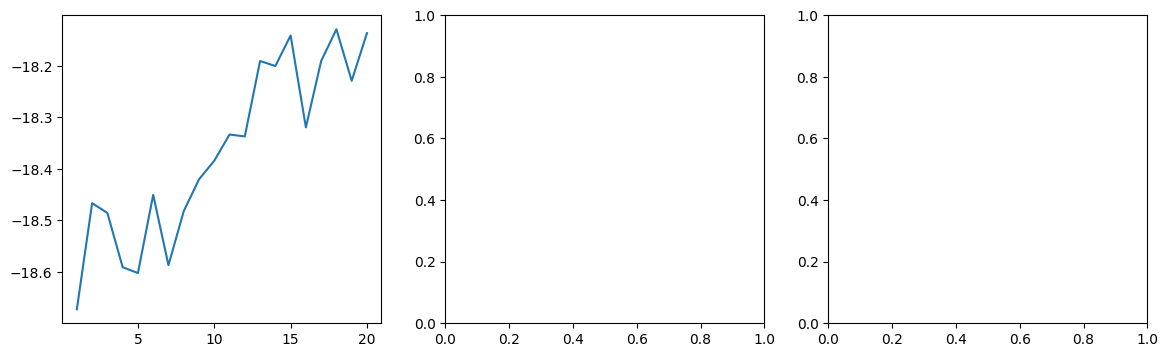

In [13]:
import matplotlib.pyplot as plt

epochs_x = list(range(1, len(history) + 1))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(epochs_x, [h['mean_reward'] for h in history], label='reward')
axes[0].plot(epochs_x, [h['baseline'] for h in history], label='baseline', linestyle='--')
axes[0].set_title('Reward promedio vs Baseline')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs_x, [h['solved_ratio'] * 100 for h in history])
axes[1].set_title('% Instancias resueltas (train)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('%')

axes[2].plot(epochs_x, [h['entropy'] for h in history])
axes[2].set_title('Entropía promedio')
axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.show()

## 9. Evaluación final — Benchmark CVS completo

Compara el modelo RL contra el modelo SL base sobre las 840 instancias CVS.

In [ ]:
# Cargar todas las instancias CVS con H real = H_archivo + 2
# Formato carpeta: H-S (primer número = altura)
all_cvs = []
all_cvs_h10 = []
for dat_file in sorted(CVS_FOLDER.rglob('*.dat')):
    try:
        H_file = int(dat_file.parent.name.split('-')[0])
        layout = read_file(str(dat_file), H=H_file + 2)
        if H_file == 10:
            all_cvs_h10.append(layout)
        else:
            all_cvs.append(layout)
    except Exception:
        pass
print(f'Instancias CVS (H_archivo<10): {len(all_cvs)}')
print(f'Instancias CVS (H_archivo=10): {len(all_cvs_h10)}')

rl_eval = trainer.evaluate(all_cvs, max_steps=100)
print(f'\nModelo RL  (H<10) → solve_rate: {rl_eval["solve_rate"]*100:.1f}% | mean_steps: {rl_eval["mean_steps"]:.2f}')

if all_cvs_h10:
    rl_eval_h10 = trainer.evaluate(all_cvs_h10, max_steps=100)
    print(f'Modelo RL  (H=10) → solve_rate: {rl_eval_h10["solve_rate"]*100:.1f}% | mean_steps: {rl_eval_h10["mean_steps"]:.2f}')

Instancias CVS (H_archivo<10): 760
Instancias CVS (H_archivo=10): 80

Modelo RL  (H<10) → solve_rate: 79.7% | mean_steps: 27.04
Modelo RL  (H=10) → solve_rate: 0.0% | mean_steps: 100.00


In [ ]:
# Comparar contra el modelo SL original
model_sl = load_model(CPMPTransformer, MODEL_NAME).to(device)
trainer_sl = RLTrainer(model=model_sl, device=device, max_steps=100)

sl_eval = trainer_sl.evaluate(all_cvs, max_steps=100)
print(f'Modelo SL  (H<10) → solve_rate: {sl_eval["solve_rate"]*100:.1f}% | mean_steps: {sl_eval["mean_steps"]:.2f}')
print(f'Modelo RL  (H<10) → solve_rate: {rl_eval["solve_rate"]*100:.1f}% | mean_steps: {rl_eval["mean_steps"]:.2f}')

if all_cvs_h10:
    sl_eval_h10 = trainer_sl.evaluate(all_cvs_h10, max_steps=100)
    print(f'\nModelo SL  (H=10) → solve_rate: {sl_eval_h10["solve_rate"]*100:.1f}% | mean_steps: {sl_eval_h10["mean_steps"]:.2f}')
    print(f'Modelo RL  (H=10) → solve_rate: {rl_eval_h10["solve_rate"]*100:.1f}% | mean_steps: {rl_eval_h10["mean_steps"]:.2f}')

print(f'\nReferencia BSG → solve_rate: 100.0% | mean_steps: 26.9')

Modelo SL  (H<10) → solve_rate: 72.5% | mean_steps: 26.27
Modelo RL  (H<10) → solve_rate: 79.7% | mean_steps: 27.04

Modelo SL  (H=10) → solve_rate: 0.0% | mean_steps: 100.00
Modelo RL  (H=10) → solve_rate: 0.0% | mean_steps: 100.00

Referencia BSG → solve_rate: 100.0% | mean_steps: 26.9


## 10. Guardar modelo RL final

In [ ]:
from training.training import save_model

RL_MODEL_NAME = 'v9_rl_50epochs'
save_model(trainer.model, RL_MODEL_NAME)
print(f'Modelo RL guardado como {RL_MODEL_NAME}.pth')